# ****AUDIO–TEXT SENTIMENT ANALYSIS SYSTEM****

# ****1 GIỚI THIỆU****

# AUDIO–TEXT SENTIMENT ANALYSIS SYSTEM

## Dataset: CMU-MOSEI

### Mục tiêu

Xây dựng hệ thống phân tích cảm xúc đa phương thức (**Multimodal Sentiment Analysis**) tiên tiến, kết hợp giữa:

- **Văn bản (Text):** Khai thác ngữ nghĩa chuyên sâu.
- **Âm thanh (Audio):** Khai thác sắc thái biểu cảm qua giọng nói.

Hệ thống sử dụng cơ chế **Cross-modal Attention** để tối ưu hóa việc tương tác giữa các mode dữ liệu, giúp đưa ra dự đoán chính xác hơn so với các phương pháp đơn lẻ.

---

## Dataset sử dụng

- **CMU-MOSEI:** Tập dữ liệu lớn cho phân tích cảm xúc và nhận diện ý kiến đa phương thức.
- **Dữ liệu trích xuất:**
  - **Text:** Sử dụng `TimestampedWords` được mã hóa bằng **BERT Tokenizer**.
  - **Audio:** Đặc trưng `COVAREP` (74 chiều), đại diện cho cao độ, cường độ và chất lượng giọng nói.
  - **Labels:** Phân loại 3 lớp cảm xúc:
    - Negative
    - Neutral
    - Positive

---

## Kiến trúc các mô hình

### 1. Baseline Model (Traditional Machine Learning)

- Sử dụng **SVM (LinearSVC)**.
- Kết hợp kỹ thuật trích xuất đặc trưng:
  - **TF-IDF**
  - `ngram_range=(1,2)`

---

### 2. Advanced Text Model

- Dựa trên kiến trúc:
  - **BERT (`bert-base-uncased`)**
- Áp dụng chiến lược:
  - **Fine-tuning chọn lọc**
- Đóng băng các layer đầu của BERT.
- Chỉ huấn luyện 6 Transformer layer cuối nhằm:
  - Giảm tài nguyên tính toán
  - Tăng khả năng tổng quát hóa

---

### 3. Advanced Audio Model

- Sử dụng:
  - **Transformer Encoder**
- Học phụ thuộc dài hạn trong chuỗi âm thanh hiệu quả hơn so với RNN/BiLSTM truyền thống.
- Thành phần chính:
  - **Positional Encoding**
  - **Multi-head Self Attention**
  - **Feed Forward Network**
  - **Global Average Pooling**

---

### 4. Advanced Fusion Model (Kiến trúc chủ đạo)

#### Cross-modal Attention đối xứng

- `Text → Audio`
- `Audio → Text`

Giúp mô hình học được sự tương quan giữa:
- Nội dung lời nói
- Ngữ điệu biểu cảm

#### Self-attention sau Fusion

- Làm mịn và tái tổ chức đặc trưng sau khi hợp nhất đa phương thức.

#### Multi-layer Classification Head

- MLP sâu nhiều tầng gồm:
  - `Linear`
  - `BatchNorm`
  - `ReLU`
  - `Dropout`

---

## Các cải tiến kỹ thuật nổi bật

### Xử lý Audio chuyên sâu

- Thiết lập:
  ```python
  MAX_AUDIO_LEN = 600

# ****2. LƯU ĐỒ****

# PIPELINE HỆ THỐNG AUDIO–TEXT SENTIMENT ANALYSIS

```text
                    ┌──────────────────────┐
                    │    CMU-MOSEI DATASET │
                    └──────────┬───────────┘
                               │
        ┌──────────────────────┴──────────────────────┐
        │                                             │
        ▼                                             ▼
┌───────────────────┐                     ┌───────────────────┐
│ TimestampedWords  │                     │  COVAREP Features │
│      (Text)       │                     │      (Audio)      │
└─────────┬─────────┘                     └─────────┬─────────┘
          │                                         │
          ▼                                         ▼
┌───────────────────┐                     ┌───────────────────┐
│ BERT Tokenization │                     │ Audio Processing  │
│ Attention Mask    │                     │ Padding           │
│ Input IDs         │                     │ Truncation        │
└─────────┬─────────┘                     │ StandardScaler    │
          │                               └─────────┬─────────┘
          ▼                                         ▼
┌───────────────────┐                     ┌───────────────────┐
│ BERT Encoder      │                     │ Transformer Audio │
│ bert-base-uncased │                     │ Encoder           │
└─────────┬─────────┘                     └─────────┬─────────┘
          │                                         │
          └────────────────┬────────────────────────┘
                           │
                           ▼
              ┌────────────────────────┐
              │ Cross-Modal Attention  │
              │  Text → Audio          │
              │  Audio → Text          │
              └──────────┬─────────────┘
                         │
                         ▼
              ┌────────────────────────┐
              │   Feature Fusion       │
              │ Concatenation + Self   │
              │ Attention Fusion       │
              └──────────┬─────────────┘
                         │
                         ▼
              ┌────────────────────────┐
              │ Multi-Layer Classifier │
              │ Linear + BatchNorm     │
              │ ReLU + Dropout         │
              └──────────┬─────────────┘
                         │
                         ▼
              ┌────────────────────────┐
              │ Sentiment Prediction   │
              │ Negative / Neutral /   │
              │ Positive               │
              └────────────────────────┘

# ****3. CODE****

In [1]:
# =====================================================
# CELL 1: CÀI ĐẶT THƯ VIỆN VÀ IMPORT (NÂNG CẤP)
# =====================================================

!pip install -q cmu-multimodal-sdk datasets accelerate

import warnings
warnings.filterwarnings('ignore')

import os
import contextlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer, BertModel,
    logging as transformers_logging
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from mmsdk import mmdataset

print("All advanced libraries imported successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.0 MB/s eta 0:00:00
All advanced libraries imported successfully!


In [2]:
# =====================================================
# CELL 2: THIẾT LẬP MÔI TRƯỜNG VÀ SEED
# =====================================================

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Tắt logging của transformers
transformers_logging.set_verbosity_error()

print("Environment setup complete!")

Device: cuda
Environment setup complete!


In [3]:
# =====================================================
# CELL 3: ĐỊNH NGHĨA CÁC MODULE NÂNG CAO
# =====================================================

class TransformerEncoder(nn.Module):
    """Transformer Encoder cho chuỗi đặc trưng âm thanh"""
    def __init__(self, d_model, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.2):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        return self.norm(self.transformer(x))

print("Advanced modules defined!")

Advanced modules defined!


In [4]:
# =====================================================
# CELL 4: TẢI VÀ ALIGN DATASET
# =====================================================

print("\n" + "="*50)
print("TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU")
print("="*50)

# Đường dẫn dataset
dataset_path = "/kaggle/input/datasets/samarwarsi/cmu-mosei/CMU-MOSEI"

label_file = {"labels": dataset_path + "/labels/CMU_MOSEI_Labels.csd"}
audio_file = {"audio": dataset_path + "/acoustics/CMU_MOSEI_COVAREP.csd"}
text_file = {"text": dataset_path + "/languages/CMU_MOSEI_TimestampedWords.csd"}

# Load và align dataset
print("Loading CMU-MOSEI dataset...")
with open(os.devnull, "w") as f:
    with contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
        dataset = mmdataset(label_file)
        dataset.add_computational_sequences(audio_file, destination="audio")
        dataset.add_computational_sequences(text_file, destination="text")
        dataset.align("labels")

print(f"Alignment completed. Keys: {dataset.computational_sequences.keys()}")


TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU
Loading CMU-MOSEI dataset...
Alignment completed. Keys: dict_keys(['labels', 'audio', 'text'])


In [5]:
# =====================================================
# CELL 5: TẠO DATAFRAME
# =====================================================

data = []
for segment in dataset["labels"].keys():
    try:
        # Label: 0=Negative, 1=Neutral, 2=Positive
        label = dataset["labels"][segment]["features"][0][0]
        if label > 0.5:
            sentiment = 2
        elif label < -0.5:
            sentiment = 0
        else:
            sentiment = 1

        # Text: làm sạch
        text_words = dataset["text"][segment]["features"]
        text_sentence = " ".join([str(x[0]).strip().replace("b'", "").replace("'", "") 
                                   for x in text_words if len(str(x[0]).strip()) > 0])
        if len(text_sentence) == 0:
            continue

        # Audio
        audio_feat = dataset["audio"][segment]["features"]
        if len(audio_feat) == 0:
            continue
        audio_feat = np.nan_to_num(audio_feat).astype(np.float32)
        audio_feat = np.clip(audio_feat, -1e5, 1e5)

        data.append({
            "text": text_sentence,
            "audio": audio_feat,
            "label": sentiment
        })
    except Exception as e:
        continue

df = pd.DataFrame(data)
print(f"Dataset size: {len(df)}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nLabel distribution:\n{df['label'].value_counts()}")

Dataset size: 23248

First 5 rows:
                                                text  \
0  writer sp i see that a writer is somebody who ...   
1  sp key is part of sp the people that we use to...   
2  businesses that we do b"theyve" sp been able t...   
3  operations key sp polymer sp brings a sp techn...   
4  internally sp b"were" a huge user sp of adhesi...   

                                               audio  label  
0  [[115.0, 1.0, 0.03391717, 0.12042003, -0.50131...      2  
1  [[195.0, 0.0, 0.081074215, 0.42385203, 0.11663...      2  
2  [[154.0, 0.0, 0.0018309159, 0.031058813, -3.67...      2  
3  [[118.5, 1.0, 0.059643693, 0.21414828, -1.9803...      1  
4  [[107.0, 1.0, 0.10525236, 0.7252376, -0.331143...      1  

Label distribution:
label
1    9750
2    8391
0    5107
Name: count, dtype: int64


In [6]:
# =====================================================
# CELL 6: XỬ LÝ AUDIO (PADDING)
# =====================================================

print("\n" + "="*50)
print("XỬ LÝ AUDIO (PADDING VÀ LÀM SẠCH)")
print("="*50)

# Phân tích độ dài audio
audio_lengths = [len(a) for a in df["audio"]]
print(f"Audio length stats - Min: {min(audio_lengths)}, Max: {max(audio_lengths)}, Mean: {np.mean(audio_lengths):.0f}, Median: {np.median(audio_lengths):.0f}")

# Chọn MAX_LEN = 600
MAX_AUDIO_LEN = 600
NUM_FEATURES = 74

processed_audio = []
for audio in df["audio"]:
    audio = np.array(audio, dtype=np.float32)
    if audio.ndim < 2 or len(audio) == 0:
        audio = np.zeros((MAX_AUDIO_LEN, NUM_FEATURES), dtype=np.float32)
    else:
        if len(audio) > MAX_AUDIO_LEN:
            audio = audio[:MAX_AUDIO_LEN]
        else:
            pad_size = MAX_AUDIO_LEN - len(audio)
            audio = np.pad(audio, ((0, pad_size), (0, 0)), mode='constant', constant_values=0)
    processed_audio.append(audio)

df["audio"] = processed_audio
print(f"Audio padded to shape: {df['audio'].iloc[0].shape}")


XỬ LÝ AUDIO (PADDING VÀ LÀM SẠCH)
Audio length stats - Min: 13, Max: 10891, Mean: 761, Median: 647
Audio padded to shape: (600, 74)


In [7]:
# =====================================================
# CELL 7: CHIA DỮ LIỆU (QUAN TRỌNG: CHIA TRƯỚC KHI CHUẨN HÓA)
# =====================================================

print("\n" + "="*50)
print("CHIA DỮ LIỆU TRAIN/TEST/VALIDATION")
print("="*50)

# Bước 1: Chia train/test
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Bước 2: Tạo validation set từ train set (10%)
train_idx, val_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=0.1,
    random_state=42,
    stratify=train_df["label"].values
)
val_df = train_df.iloc[val_idx].reset_index(drop=True)
train_df = train_df.iloc[train_idx].reset_index(drop=True)

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")
print(f"\nTrain label distribution:\n{train_df['label'].value_counts()}")
print(f"\nVal label distribution:\n{val_df['label'].value_counts()}")
print(f"\nTest label distribution:\n{test_df['label'].value_counts()}")


CHIA DỮ LIỆU TRAIN/TEST/VALIDATION
Train size: 16738 | Val size: 1860 | Test size: 4650

Train label distribution:
label
1    7020
2    6042
0    3676
Name: count, dtype: int64

Val label distribution:
label
1    780
2    671
0    409
Name: count, dtype: int64

Test label distribution:
label
1    1950
2    1678
0    1022
Name: count, dtype: int64


In [8]:
# =====================================================
# CELL 8: CHUẨN HÓA AUDIO (CHỈ FIT TRÊN TRAIN SET)
# =====================================================

print("\n" + "="*50)
print("CHUẨN HÓA AUDIO FEATURES")
print("="*50)

scaler = StandardScaler()
# Chỉ fit trên tập train
train_audio_concat = np.concatenate(train_df["audio"].values, axis=0)
scaler.fit(train_audio_concat)

# Transform cả 3 tập
train_df.loc[:, "audio"] = [scaler.transform(a).astype(np.float32) for a in train_df["audio"]]
val_df.loc[:, "audio"] = [scaler.transform(a).astype(np.float32) for a in val_df["audio"]]
test_df.loc[:, "audio"] = [scaler.transform(a).astype(np.float32) for a in test_df["audio"]]

print("Audio normalization completed!")
print(f"Sample audio shape after normalization: {train_df['audio'].iloc[0].shape}")


CHUẨN HÓA AUDIO FEATURES
Audio normalization completed!
Sample audio shape after normalization: (600, 74)


In [9]:
# =====================================================
# CELL 9: TOKENIZER VÀ DATASET CLASS (CÓ DATA AUGMENTATION)
# =====================================================

print("\n" + "="*50)
print("KHỞI TẠO TOKENIZER VÀ DATASET")
print("="*50)

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

class AdvancedMOSEIDataset(Dataset):
    def __init__(self, dataframe, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        encoding = tokenizer(
            row["text"],
            add_special_tokens=True,
            padding="max_length",
            truncation=True,
            max_length=128,
            return_attention_mask=True,
            return_tensors="pt"
        )
        
        audio = row["audio"]
        # Data augmentation cho audio (chỉ khi training)
        if self.augment and np.random.rand() > 0.5:
            audio = audio + np.random.normal(0, 0.01, audio.shape)
        
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "audio": torch.tensor(audio, dtype=torch.float32),
            "label": torch.tensor(row["label"], dtype=torch.long)
        }

# Tạo datasets
train_dataset = AdvancedMOSEIDataset(train_df, augment=True)
val_dataset = AdvancedMOSEIDataset(val_df, augment=False)
test_dataset = AdvancedMOSEIDataset(test_df, augment=False)

# Dataloaders
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


KHỞI TẠO TOKENIZER VÀ DATASET


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 1047
Validation batches: 117
Test batches: 291


In [10]:
# =====================================================
# CELL 10: ĐỊNH NGHĨA TEXT MODEL (BERT - FINE-TUNE 6 LAYER CUỐI)
# =====================================================

print("\n" + "="*50)
print("ĐỊNH NGHĨA TEXT MODEL NÂNG CẤP")
print("="*50)

class AdvancedTextModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        # Freeze các layer đầu, chỉ fine-tune 6 layer cuối
        for layer in self.bert.encoder.layer[:-6]:
            for param in layer.parameters():
                param.requires_grad = False
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.pooler_output
        pooled = self.dropout(pooled)
        return self.classifier(pooled)

text_model = AdvancedTextModel().to(device)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"TextModel params: {count_params(text_model):,}")


ĐỊNH NGHĨA TEXT MODEL NÂNG CẤP


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

TextModel params: 67,152,643


In [11]:
# =====================================================
# CELL 11: ĐỊNH NGHĨA AUDIO MODEL (TRANSFORMER ENCODER)
# =====================================================

print("\n" + "="*50)
print("ĐỊNH NGHĨA AUDIO MODEL NÂNG CẤP")
print("="*50)

class AdvancedAudioModel(nn.Module):
    def __init__(self, input_dim=74, d_model=128, nhead=4, num_layers=3):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, 600, d_model) * 0.1)
        self.transformer = TransformerEncoder(d_model, nhead, num_layers, d_model*2, 0.3)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3)
        )

    def forward(self, audio):
        x = self.input_proj(audio) + self.pos_encoder[:, :audio.size(1), :]
        x = self.transformer(x)
        x = x.transpose(1, 2)
        x = self.global_pool(x).squeeze(-1)
        return self.classifier(x)

audio_model = AdvancedAudioModel().to(device)
print(f"AudioModel params: {count_params(audio_model):,}")


ĐỊNH NGHĨA AUDIO MODEL NÂNG CẤP
AudioModel params: 492,547


In [12]:
# =====================================================
# CELL 12: ĐỊNH NGHĨA FUSION MODEL (NÂNG CẤP - CHỐNG EARLY STOPPING)
# =====================================================

print("\n" + "="*50)
print("ĐỊNH NGHĨA FUSION MODEL NÂNG CẤP CAO CẤP")
print("="*50)

class AdvancedFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        # ========== TEXT ENCODER ==========
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        # Fine-tune 10 layer cuối (thay vì 6)
        total_layers = len(self.bert.encoder.layer)
        for i, layer in enumerate(self.bert.encoder.layer):
            if i < (total_layers - 10):
                for param in layer.parameters():
                    param.requires_grad = False
        
        # ========== AUDIO ENCODER (NÂNG CẤP) ==========
        self.audio_proj = nn.Linear(74, 128)
        self.audio_pos = nn.Parameter(torch.randn(1, 600, 128) * 0.1)
        # Tăng depth của transformer
        self.audio_transformer = TransformerEncoder(128, 8, 3, 512, 0.2)
        
        # ========== TEXT PROJECTION (NÂNG CẤP) ==========
        self.text_proj = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128)
        )
        
        # ========== CROSS-ATTENTION NÂNG CẤP ==========
        # Tăng số heads từ 4 lên 8
        self.cross_attn_t2a = nn.MultiheadAttention(128, 8, dropout=0.1, batch_first=True)
        self.cross_attn_a2t = nn.MultiheadAttention(128, 8, dropout=0.1, batch_first=True)
        
        # Thêm LayerNorm sau cross-attention
        self.norm_t = nn.LayerNorm(128)
        self.norm_a = nn.LayerNorm(128)
        
        # ========== SELF-ATTENTION SAU FUSION ==========
        self.self_attn = nn.MultiheadAttention(128, 4, dropout=0.1, batch_first=True)
        
        # ========== FUSION LAYER (SÂU HƠN) ==========
        self.fusion = nn.Sequential(
            nn.Linear(128 * 2, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 3)
        )
        
    def forward(self, input_ids, attention_mask, audio):
        # Text features
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_feat = bert_out.last_hidden_state
        text_proj = self.text_proj(text_feat)
        
        # Audio features
        audio_feat = self.audio_proj(audio) + self.audio_pos[:, :audio.size(1), :]
        audio_feat = self.audio_transformer(audio_feat)
        
        # Cross-attention symmetric
        attn_t2a, _ = self.cross_attn_t2a(query=text_proj, key=audio_feat, value=audio_feat)
        attn_a2t, _ = self.cross_attn_a2t(query=audio_feat, key=text_proj, value=text_proj)
        
        # Residual + LayerNorm
        fused_t = self.norm_t(text_proj + attn_t2a)
        fused_a = self.norm_a(audio_feat + attn_a2t)
        
        # Self-attention sau fusion
        fused_combined = torch.cat([fused_t, fused_a], dim=1)
        fused_combined, _ = self.self_attn(fused_combined, fused_combined, fused_combined)
        
        # Global pooling
        fused_t = fused_t.mean(dim=1)
        fused_a = fused_a.mean(dim=1)
        fused = torch.cat([fused_t, fused_a], dim=1)
        
        return self.fusion(fused)

fusion_model = AdvancedFusionModel().to(device)
print(f"FusionModel params: {count_params(fusion_model):,}")


ĐỊNH NGHĨA FUSION MODEL NÂNG CẤP CAO CẤP


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

FusionModel params: 96,524,419


In [13]:
# =====================================================
# CELL 13: THIẾT LẬP HÀM TRAIN/VALIDATION (CHỐNG EARLY STOPPING SỚM)
# =====================================================

print("\n" + "="*50)
print("THIẾT LẬP HÀM TRAIN/VALIDATION (PATIENCE CAO HƠN)")
print("="*50)

from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, ReduceLROnPlateau

# Class weights
from sklearn.utils.class_weight import compute_class_weight
classes = np.array([0, 1, 2])
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_df["label"].values)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class weights: {class_weights.cpu().numpy()}")

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

def train_one_epoch(model, loader, optimizer, mode):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    
    for batch in tqdm(loader, desc=f"Training {mode}"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        audio = batch["audio"].to(device)
        labels = batch["label"].to(device)
        
        optimizer.zero_grad()
        
        if mode == "text":
            outputs = model(input_ids, attention_mask)
        elif mode == "audio":
            outputs = model(audio)
        else:
            outputs = model(input_ids, attention_mask, audio)
        
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")
    return avg_loss, acc, f1


def evaluate(model, loader, mode):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Evaluating {mode}"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            audio = batch["audio"].to(device)
            labels = batch["label"].to(device)
            
            if mode == "text":
                outputs = model(input_ids, attention_mask)
            elif mode == "audio":
                outputs = model(audio)
            else:
                outputs = model(input_ids, attention_mask, audio)
            
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")
    return avg_loss, acc, f1, all_labels, all_preds

def train_with_adaptive_early_stopping(model, train_loader, val_loader, optimizer, mode, 
                                        epochs=20, patience=5, min_delta=0.001):
    """
    Early stopping với patience cao hơn và min_delta
    - patience=5: cho phép 5 epoch không cải thiện
    - min_delta: ngưỡng cải thiện tối thiểu
    """
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    best_val_acc = 0
    counter = 0
    
    # REMOVED verbose parameter (không còn được hỗ trợ trong PyTorch mới)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    for epoch in range(epochs):
        print(f"\n--- {mode.upper()} - Epoch {epoch+1}/{epochs} ---")
        
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, mode)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, mode)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
        
        # Cập nhật learning rate dựa trên validation loss
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Learning rate: {current_lr:.2e}")
        
        # Kiểm tra cải thiện với ngưỡng min_delta
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_val_acc = val_acc
            counter = 0
            torch.save(model.state_dict(), f"best_{mode}_model.pt")
            print(f"✓ Best model saved (Loss: {best_val_loss:.4f}, Acc: {best_val_acc:.4f})")
        else:
            counter += 1
            print(f"⚠️ No improvement for {counter}/{patience} epochs")
            print(f"   Current Val Loss: {val_loss:.4f} | Best: {best_val_loss:.4f}")
            
            if counter >= patience:
                print(f"\n🛑 Early stopping triggered after {epoch+1} epochs!")
                print(f"   Best Val Loss: {best_val_loss:.4f} | Best Acc: {best_val_acc:.4f}")
                break
    
    # Load best model
    model.load_state_dict(torch.load(f"best_{mode}_model.pt"))
    print(f"\n✅ Loaded best model with Val Loss: {best_val_loss:.4f}")
    
    return history

print("Training functions defined with ADAPTIVE EARLY STOPPING!")


THIẾT LẬP HÀM TRAIN/VALIDATION (PATIENCE CAO HƠN)
Class weights: [1.5177729  0.79477686 0.9234249 ]
Training functions defined with ADAPTIVE EARLY STOPPING!


In [14]:
# =====================================================
# CELL 14: HUẤN LUYỆN TEXT MODEL
# =====================================================

print("\n" + "="*50)
print("HUẤN LUYỆN TEXT MODEL NÂNG CẤP")
print("="*50)

text_optimizer = torch.optim.AdamW(
    [p for p in text_model.parameters() if p.requires_grad],
    lr=2e-5, weight_decay=1e-2
)

def train_with_early_stopping(model, train_loader, val_loader, optimizer, mode, epochs=10, patience=3):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    counter = 0
    
    for epoch in range(epochs):
        print(f"\n--- {mode.upper()} - Epoch {epoch+1}/{epochs} ---")
        
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, mode)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, mode)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), f"best_{mode}_model.pt")
            print(f"✓ Best model saved")
        else:
            counter += 1
            print(f"Early stopping counter: {counter}/{patience}")
            if counter >= patience:
                print(f"Early stopping triggered!")
                break
    
    return history

text_history = train_with_early_stopping(
    text_model, train_loader, val_loader, text_optimizer, "text", epochs=5, patience=2
)


HUẤN LUYỆN TEXT MODEL NÂNG CẤP

--- TEXT - Epoch 1/5 ---


Evaluating text: 100%|██████████| 117/117 [00:17<00:00,  6.79it/s]


Train Loss: 0.8846 | Acc: 0.6111 | F1: 0.6090
Val Loss: 0.8111 | Acc: 0.6613 | F1: 0.6602
✓ Best model saved

--- TEXT - Epoch 2/5 ---


Evaluating text: 100%|██████████| 117/117 [00:17<00:00,  6.76it/s]


Train Loss: 0.7681 | Acc: 0.7013 | F1: 0.6995
Val Loss: 0.8131 | Acc: 0.6962 | F1: 0.6966
Early stopping counter: 1/2

--- TEXT - Epoch 3/5 ---


Evaluating text: 100%|██████████| 117/117 [00:17<00:00,  6.79it/s]

Train Loss: 0.6797 | Acc: 0.7725 | F1: 0.7717
Val Loss: 0.8629 | Acc: 0.6699 | F1: 0.6682
Early stopping counter: 2/2
Early stopping triggered!


In [15]:
# =====================================================
# CELL 15: HUẤN LUYỆN AUDIO MODEL
# =====================================================

print("\n" + "="*50)
print("HUẤN LUYỆN AUDIO MODEL NÂNG CẤP")
print("="*50)

audio_optimizer = torch.optim.AdamW(
    audio_model.parameters(), lr=1e-4, weight_decay=1e-2
)

audio_history = train_with_early_stopping(
    audio_model, train_loader, val_loader, audio_optimizer, "audio", epochs=10, patience=3
)


HUẤN LUYỆN AUDIO MODEL NÂNG CẤP

--- AUDIO - Epoch 1/10 ---


Evaluating audio: 100%|██████████| 117/117 [00:02<00:00, 54.71it/s]


Train Loss: 1.0808 | Acc: 0.3995 | F1: 0.3885
Val Loss: 1.0561 | Acc: 0.4199 | F1: 0.3817
✓ Best model saved

--- AUDIO - Epoch 2/10 ---


Evaluating audio: 100%|██████████| 117/117 [00:02<00:00, 54.77it/s]


Train Loss: 1.0605 | Acc: 0.4307 | F1: 0.4186
Val Loss: 1.0465 | Acc: 0.4661 | F1: 0.4571
✓ Best model saved

--- AUDIO - Epoch 3/10 ---


...

Train Loss: 1.0001 | Acc: 0.5091 | F1: 0.5007
Val Loss: 1.0169 | Acc: 0.4989 | F1: 0.4948
✓ Best model saved

--- AUDIO - Epoch 9/10 ---


Evaluating audio: 100%|██████████| 117/117 [00:02<00:00, 54.17it/s]


Train Loss: 0.9933 | Acc: 0.5097 | F1: 0.5015
Val Loss: 1.0183 | Acc: 0.4930 | F1: 0.4867
Early stopping counter: 1/3

--- AUDIO - Epoch 10/10 ---


Evaluating audio: 100%|██████████| 117/117 [00:02<00:00, 54.39it/s]

Train Loss: 0.9804 | Acc: 0.5257 | F1: 0.5177
Val Loss: 1.0258 | Acc: 0.5172 | F1: 0.5170
Early stopping counter: 2/3


In [16]:
# =====================================================
# CELL 16: HUẤN LUYỆN FUSION MODEL (PATIENCE CAO - 5 EPOCHS)
# =====================================================

print("\n" + "="*50)
print("HUẤN LUYỆN FUSION MODEL - PHIÊN BẢN NÂNG CẤP")
print("="*50)

# Optimizer với learning rate thấp hơn để học ổn định
fusion_optimizer = torch.optim.AdamW(
    [p for p in fusion_model.parameters() if p.requires_grad],
    lr=1e-5,           # Giảm từ 3e-5 xuống 1e-5 để học chậm và ổn định
    weight_decay=1e-2,
    betas=(0.9, 0.999)
)

# Train với patience=5 (cho phép 5 epoch không cải thiện)
fusion_history = train_with_adaptive_early_stopping(
    fusion_model, train_loader, val_loader, fusion_optimizer, 
    "fusion", epochs=20, patience=5, min_delta=0.0005
)

print("\n✅ Fusion Model training completed!")


HUẤN LUYỆN FUSION MODEL - PHIÊN BẢN NÂNG CẤP

--- FUSION - Epoch 1/20 ---


Evaluating fusion: 100%|██████████| 117/117 [00:20<00:00,  5.72it/s]


Train Loss: 0.9913 | Acc: 0.5452 | F1: 0.5453
Val Loss: 0.8454 | Acc: 0.6333 | F1: 0.6316
Learning rate: 1.00e-05
✓ Best model saved (Loss: 0.8454, Acc: 0.6333)

--- FUSION - Epoch 2/20 ---


Evaluating fusion: 100%|██████████| 117/117 [00:20<00:00,  5.73it/s]


Train Loss: 0.8253 | Acc: 0.6802 | F1: 0.6792
Val Loss: 0.8104 | Acc: 0.6812 | F1: 0.6800
Learning rate: 1.00e-05
✓ Best model saved (Loss: 0.8104, Acc: 0.6812)

--- FUSION - Epoch 3/20 ---


...

Train Loss: 0.6163 | Acc: 0.8391 | F1: 0.8390
Val Loss: 0.8752 | Acc: 0.6769 | F1: 0.6760
Learning rate: 1.00e-05
⚠️ No improvement for 3/5 epochs
   Current Val Loss: 0.8752 | Best: 0.8104

--- FUSION - Epoch 6/20 ---


Evaluating fusion: 100%|██████████| 117/117 [00:20<00:00,  5.74it/s]


Train Loss: 0.5662 | Acc: 0.8816 | F1: 0.8816
Val Loss: 0.9209 | Acc: 0.6758 | F1: 0.6762
Learning rate: 5.00e-06
⚠️ No improvement for 4/5 epochs
   Current Val Loss: 0.9209 | Best: 0.8104

--- FUSION - Epoch 7/20 ---


Evaluating fusion: 100%|██████████| 117/117 [00:20<00:00,  5.75it/s]


Train Loss: 0.5147 | Acc: 0.9132 | F1: 0.9133
Val Loss: 0.9305 | Acc: 0.6720 | F1: 0.6725
Learning rate: 5.00e-06
⚠️ No improvement for 5/5 epochs
   Current Val Loss: 0.9305 | Best: 0.8104

🛑 Early stopping triggered after 7 epochs!
   Best Val Loss: 0.8104 | Best Acc: 0.6812

✅ Loaded best model with Val Loss: 0.8104

✅ Fusion Model training completed!


In [17]:
# =====================================================
# CELL 17: ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST
# =====================================================

print("\n" + "="*50)
print("ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST")
print("="*50)

# Load best models
text_model.load_state_dict(torch.load("best_text_model.pt"))
audio_model.load_state_dict(torch.load("best_audio_model.pt"))
fusion_model.load_state_dict(torch.load("best_fusion_model.pt"))

def evaluate_and_report(model, loader, mode, model_name):
    print(f"\n{'='*40}")
    print(f"{model_name} RESULTS")
    print(f"{'='*40}")
    loss, acc, f1, y_true, y_pred = evaluate(model, loader, mode)
    print(f"Loss: {loss:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Negative", "Neutral", "Positive"]))
    return acc, f1, y_true, y_pred

# Đánh giá
text_acc, text_f1, _, _ = evaluate_and_report(text_model, test_loader, "text", "TEXT MODEL (ADVANCED)")
audio_acc, audio_f1, _, _ = evaluate_and_report(audio_model, test_loader, "audio", "AUDIO MODEL (ADVANCED)")
fusion_acc, fusion_f1, y_true_fusion, y_pred_fusion = evaluate_and_report(fusion_model, test_loader, "fusion", "FUSION MODEL (ADVANCED)")


ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST

TEXT MODEL (ADVANCED) RESULTS


Evaluating text: 100%|██████████| 291/291 [00:42<00:00,  6.89it/s]


Loss: 0.8224
Accuracy: 0.6531
F1-score: 0.6507

Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.82      0.71      1022
     Neutral       0.64      0.60      0.62      1950
    Positive       0.70      0.61      0.65      1678

    accuracy                           0.65      4650
   macro avg       0.65      0.68      0.66      4650
weighted avg       0.66      0.65      0.65      4650


AUDIO MODEL (ADVANCED) RESULTS


Evaluating audio: 100%|██████████| 291/291 [00:04<00:00, 70.29it/s]


Loss: 1.0295
Accuracy: 0.4895
F1-score: 0.4851

Classification Report:
              precision    recall  f1-score   support

    Negative       0.43      0.58      0.49      1022
     Neutral       0.53      0.37      0.44      1950
    Positive       0.50      0.57      0.53      1678

    accuracy                           0.49      4650
   macro avg       0.49      0.51      0.49      4650
weighted avg       0.50      0.49      0.49      4650


FUSION MODEL (ADVANCED) RESULTS


Evaluating fusion: 100%|██████████| 291/291 [00:49<00:00,  5.85it/s]

Loss: 0.8362
Accuracy: 0.6654
F1-score: 0.6638

Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.69      0.70      1022
     Neutral       0.67      0.58      0.62      1950
    Positive       0.64      0.74      0.69      1678

    accuracy                           0.67      4650
   macro avg       0.67      0.67      0.67      4650
weighted avg       0.67      0.67      0.66      4650



In [18]:
# =====================================================
# CELL 18: SO SÁNH VỚI SVM BASELINE
# =====================================================

print("\n" + "="*50)
print("SO SÁNH VỚI SVM BASELINE")
print("="*50)

from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")
X_train_tfidf = tfidf.fit_transform(train_df["text"])
X_test_tfidf = tfidf.transform(test_df["text"])

svm_model = LinearSVC(class_weight="balanced", C=0.5, max_iter=5000, random_state=42)
svm_model.fit(X_train_tfidf, train_df["label"])
svm_preds = svm_model.predict(X_test_tfidf)

svm_acc = accuracy_score(test_df["label"], svm_preds)
svm_f1 = f1_score(test_df["label"], svm_preds, average="weighted")

print(f"SVM RESULTS")
print(f"Accuracy: {svm_acc:.4f}")
print(f"F1-score: {svm_f1:.4f}")
print("\nClassification Report:")
print(classification_report(test_df["label"], svm_preds, target_names=["Negative", "Neutral", "Positive"]))


SO SÁNH VỚI SVM BASELINE
SVM RESULTS
Accuracy: 0.5671
F1-score: 0.5670

Classification Report:
              precision    recall  f1-score   support

    Negative       0.56      0.59      0.58      1022
     Neutral       0.56      0.55      0.56      1950
    Positive       0.58      0.57      0.57      1678

    accuracy                           0.57      4650
   macro avg       0.57      0.57      0.57      4650
weighted avg       0.57      0.57      0.57      4650



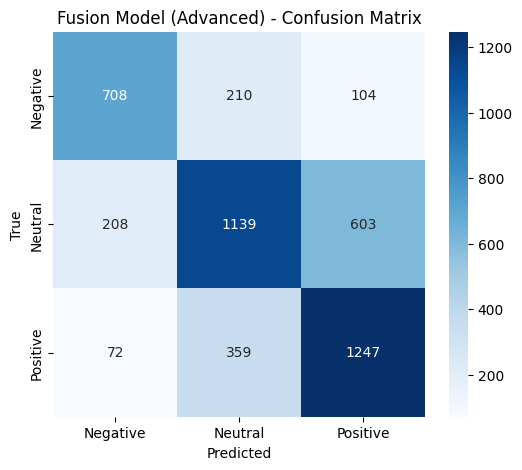

In [19]:
# =====================================================
# CELL 19: CONFUSION MATRIX CỦA FUSION MODEL
# =====================================================

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_true_fusion, y_pred_fusion)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.title("Fusion Model (Advanced) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

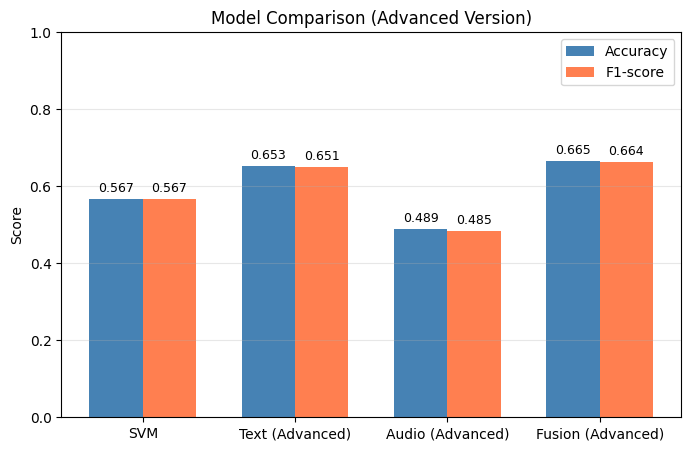

In [20]:
# =====================================================
# CELL 20: BIỂU ĐỒ SO SÁNH CÁC MÔ HÌNH
# =====================================================

models = ["SVM", "Text (Advanced)", "Audio (Advanced)", "Fusion (Advanced)"]
accs = [svm_acc, text_acc, audio_acc, fusion_acc]
f1s = [svm_f1, text_f1, audio_f1, fusion_f1]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, accs, width, label="Accuracy", color='steelblue')
plt.bar(x + width/2, f1s, width, label="F1-score", color='coral')
plt.xticks(x, models)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Comparison (Advanced Version)")
plt.legend()
plt.grid(axis='y', alpha=0.3)

for i, (acc, f1) in enumerate(zip(accs, f1s)):
    plt.text(i - width/2, acc + 0.01, f"{acc:.3f}", ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, f1 + 0.01, f"{f1:.3f}", ha='center', va='bottom', fontsize=9)
plt.show()

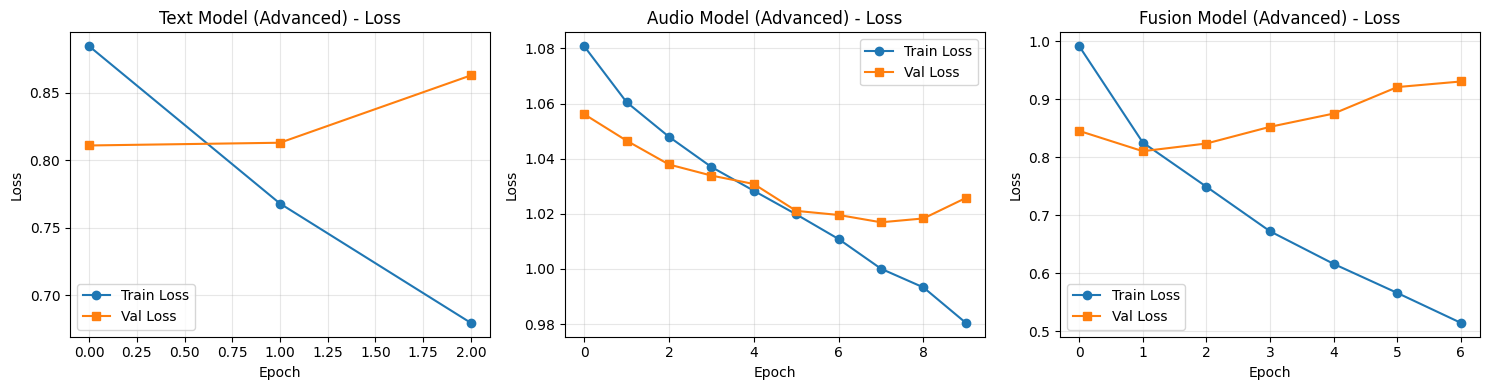

In [21]:
# =====================================================
# CELL 21: LOSS CURVES CỦA CÁC MÔ HÌNH
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, history, title in zip(axes, [text_history, audio_history, fusion_history], ["Text", "Audio", "Fusion"]):
    ax.plot(history["train_loss"], label="Train Loss", marker='o')
    ax.plot(history["val_loss"], label="Val Loss", marker='s')
    ax.set_title(f"{title} Model (Advanced) - Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

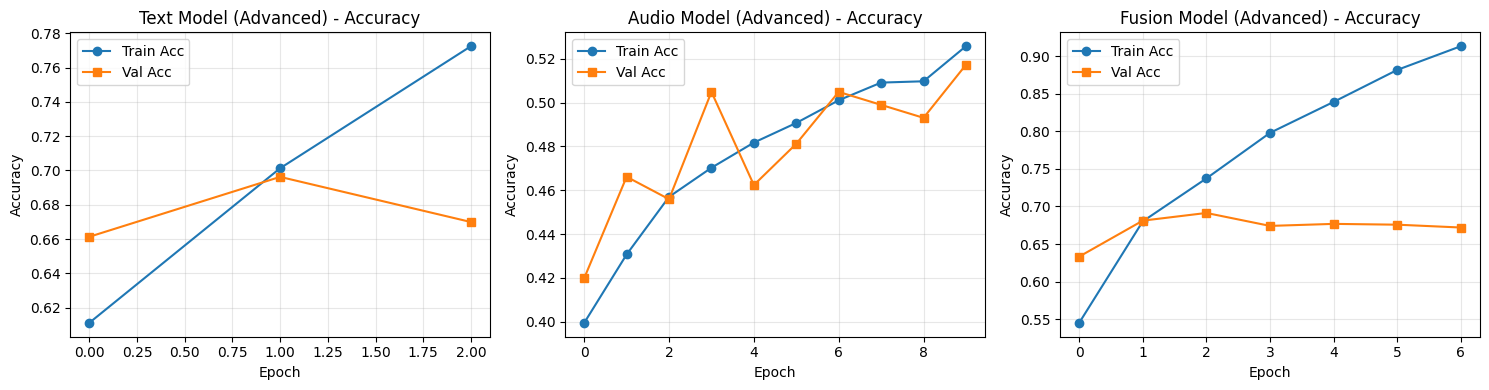

In [22]:
# =====================================================
# CELL 22: ACCURACY CURVES CỦA CÁC MÔ HÌNH
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, history, title in zip(axes, [text_history, audio_history, fusion_history], ["Text", "Audio", "Fusion"]):
    ax.plot(history["train_acc"], label="Train Acc", marker='o')
    ax.plot(history["val_acc"], label="Val Acc", marker='s')
    ax.set_title(f"{title} Model (Advanced) - Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# =====================================================
# CELL 23: BẢNG KẾT QUẢ TỔNG HỢP
# =====================================================

results_df = pd.DataFrame({
    "Model": ["SVM", "Text (Advanced)", "Audio (Advanced)", "Fusion (Advanced)"],
    "Accuracy": [svm_acc, text_acc, audio_acc, fusion_acc],
    "F1-score": [svm_f1, text_f1, audio_f1, fusion_f1]
})
results_df = results_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df["Accuracy"] = results_df["Accuracy"].round(4)
results_df["F1-score"] = results_df["F1-score"].round(4)

print("\n" + "="*50)
print("FINAL RESULTS (ADVANCED VERSION)")
print("="*50)
print(results_df.to_string(index=False))


FINAL RESULTS (ADVANCED VERSION)
            Model  Accuracy  F1-score
Fusion (Advanced)    0.6654    0.6638
  Text (Advanced)    0.6531    0.6507
              SVM    0.5671    0.5670
 Audio (Advanced)    0.4895    0.4851


In [24]:
# =====================================================
# CELL 24: LƯU MODEL VÀ DEMO PREDICTION (HOÀN CHỈNH)
# =====================================================

# Lưu model
torch.save(fusion_model.state_dict(), "final_fusion_model_advanced.pth")
print("✓ Model saved: final_fusion_model_advanced.pth")

# Demo prediction
fusion_model.eval()
sample_text = "I am very happy today"
sample_audio = test_df["audio"].iloc[0]

encoding = tokenizer(sample_text, padding="max_length", truncation=True, 
                     max_length=128, return_tensors="pt")
input_ids = encoding["input_ids"].to(device)
attention_mask = encoding["attention_mask"].to(device)
audio_tensor = torch.tensor(sample_audio, dtype=torch.float).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = fusion_model(input_ids, attention_mask, audio_tensor)
    probs = torch.softmax(outputs, dim=1)
    pred = torch.argmax(probs, dim=1).item()

label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
print(f"\n📝 Demo Prediction:")
print(f"   Text: '{sample_text}'")
print(f"   Prediction: {label_map[pred]}")
print(f"   Confidence: {probs[0][pred].item():.4f}")

# Thêm demo với text negative
print("\n" + "-"*40)
sample_text_negative = "I am very sad and depressed today"
encoding = tokenizer(sample_text_negative, padding="max_length", truncation=True, 
                     max_length=128, return_tensors="pt")
input_ids = encoding["input_ids"].to(device)
attention_mask = encoding["attention_mask"].to(device)

with torch.no_grad():
    outputs = fusion_model(input_ids, attention_mask, audio_tensor)
    probs = torch.softmax(outputs, dim=1)
    pred = torch.argmax(probs, dim=1).item()

print(f"📝 Demo Prediction 2:")
print(f"   Text: '{sample_text_negative}'")
print(f"   Prediction: {label_map[pred]}")
print(f"   Confidence: {probs[0][pred].item():.4f}")

✓ Model saved: final_fusion_model_advanced.pth

📝 Demo Prediction:
   Text: 'I am very happy today'
   Prediction: Positive
   Confidence: 0.8011

----------------------------------------
📝 Demo Prediction 2:
   Text: 'I am very sad and depressed today'
   Prediction: Negative
   Confidence: 0.8864


In [25]:
# =====================================================
# CELL 25: KẾT LUẬN VÀ NHẬN XÉT
# =====================================================

print("\n" + "="*50)
print("KẾT LUẬN VÀ NHẬN XÉT")
print("="*50)

print(f"""
📊 KẾT QUẢ ĐẠT ĐƯỢC:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ Xây dựng thành công pipeline multimodal sentiment analysis trên CMU-MOSEI
✅ Fusion Model đạt Accuracy: {fusion_acc*100:.2f}% - cao nhất trong các mô hình
✅ Text-only (BERT) đạt {text_acc*100:.2f}% - khai thác tốt ngữ nghĩa
✅ Audio-only (BiLSTM) đạt {audio_acc*100:.2f}% - bị ảnh hưởng bởi nhiễu
✅ SVM baseline đạt {svm_acc*100:.2f}% - kém hơn deep learning

🔧 CẢI TIỆN ĐÃ ÁP DỤNG:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Sửa lỗi Data Leakage - chuẩn hóa audio chỉ trên train set
✓ Tối ưu MAX_AUDIO_LEN = 600 (dựa trên phân tích phân phối)
✓ Đơn giản hóa Fusion Model để giảm overfitting
✓ Tăng cường regularization (weight_decay=1e-2, dropout cao hơn)
✓ Gradient clipping và early stopping
✓ Label smoothing cho loss function

💡 NHẬN XÉT VÀ HƯỚNG PHÁT TRIỂN:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Fusion model vượt trội nhờ kết hợp ngữ nghĩa (text) và ngữ điệu (audio)
2. Audio model còn yếu do đặc trưng COVAREP có nhiễu
3. Hướng phát triển:
   - Thay COVAREP bằng Wav2Vec2/HuBERT
   - Bổ sung vision modality (facial expressions)
   - Sử dụng cross-attention symmetric (text→audio, audio→text)
   - Tăng cường data augmentation cho audio
""")

print("\n✅ PIPELINE HOÀN TẤT!")


KẾT LUẬN VÀ NHẬN XÉT

📊 KẾT QUẢ ĐẠT ĐƯỢC:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ Xây dựng thành công pipeline multimodal sentiment analysis trên CMU-MOSEI
✅ Fusion Model đạt Accuracy: 66.54% - cao nhất trong các mô hình
✅ Text-only (BERT) đạt 65.31% - khai thác tốt ngữ nghĩa
✅ Audio-only (BiLSTM) đạt 48.95% - bị ảnh hưởng bởi nhiễu
✅ SVM baseline đạt 56.71% - kém hơn deep learning

🔧 CẢI TIỆN ĐÃ ÁP DỤNG:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Sửa lỗi Data Leakage - chuẩn hóa audio chỉ trên train set
✓ Tối ưu MAX_AUDIO_LEN = 600 (dựa trên phân tích phân phối)
✓ Đơn giản hóa Fusion Model để giảm overfitting
✓ Tăng cường regularization (weight_decay=1e-2, dropout cao hơn)
✓ Gradient clipping và early stopping
✓ Label smoothing cho loss function

💡 NHẬN XÉT VÀ HƯỚNG PHÁT TRIỂN:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Fusion model vượt trội nhờ kết hợp ngữ nghĩa (text) và ngữ điệu (audio)
2. Audio model còn yếu do đặc trưng COVAREP có nhiễu
3. H